# API Endpoints for Model Comparison, Performance Benchmarking, and Ensemble Models

This notebook demonstrates how to use the backend API for model comparison, performance benchmarking, and ensemble/hybrid model predictions. It also visualizes the results for easy interpretation.

---

## 1. Add Endpoints for Model Comparison

We have implemented an endpoint `/api/compare/models` that accepts multiple models and a text input, returning predictions and probabilities for each model. This allows direct comparison of model outputs on the same input.

In [1]:
import requests
import json

# Example input for model comparison
text = "The government has announced a new policy to support renewable energy."
models = ["distilbert", "albert", "logistic_regression"]

response = requests.post(
    "http://localhost:8000/api/compare/models",
    json={"text": text, "models": models}
)

comparison_results = response.json()
print(json.dumps(comparison_results, indent=2))

{
  "detail": [
    {
      "type": "missing",
      "loc": [
        "query",
        "text"
      ],
      "msg": "Field required",
      "input": null
    },
    {
      "type": "list_type",
      "loc": [
        "body"
      ],
      "msg": "Input should be a valid list",
      "input": {
        "text": "The government has announced a new policy to support renewable energy.",
        "models": [
          "distilbert",
          "albert",
          "logistic_regression"
        ]
      }
    }
  ]
}


## 2. Add Endpoints for Performance Benchmarking

The `/api/compare/performance` endpoint returns performance metrics (accuracy, precision, recall, F1-score, latency, etc.) for all models, as computed on the test set. This enables easy benchmarking and comparison of model quality and efficiency.

In [2]:
# Get model performance metrics
perf_response = requests.get("http://localhost:8000/api/compare/performance")
performance_metrics = perf_response.json()
import pandas as pd
perf_df = pd.DataFrame.from_dict(performance_metrics, orient='index')
display(perf_df)


,performance,resources
logistic_regression,"{'accuracy': 0.9064509437875959, 'f1_score': 0...","{'memory_mb': 415.5, 'avg_inference_ms': 0.287}"
naive_bayes,"{'accuracy': 0.8751296411532877, 'f1_score': 0...","{'memory_mb': 409.28, 'avg_inference_ms': 0.2043}"
svm,"{'accuracy': 0.9089400539307197, 'f1_score': 0...","{'memory_mb': 407.47, 'avg_inference_ms': 0.1901}"
distilbert,"{'accuracy': 0.9249118440157643, 'f1_score': 0...","{'memory_mb': 141.36, 'avg_inference_ms': 7.0807}"
albert,"{'accuracy': 0.9242895664799834, 'f1_score': 0...","{'memory_mb': 16.12, 'avg_inference_ms': 20.6612}"


## 3. Add Endpoints for Ensemble and Hybrid Models

The `/api/ensemble/ensemble` endpoint allows you to get predictions from an ensemble of models using majority voting. This can be extended to support hybrid models (e.g., transformer + LSTM) as needed.

In [3]:
# Example: Ensemble prediction using majority voting
ensemble_models = ["distilbert", "albert", "logistic_regression"]
ensemble_response = requests.post(
    "http://localhost:8000/api/ensemble/ensemble",
    json={"text": text, "models": ensemble_models}
)
ensemble_result = ensemble_response.json()
print(ensemble_result)

{'detail': [{'type': 'missing', 'loc': ['query', 'text'], 'msg': 'Field required', 'input': None}, {'type': 'missing', 'loc': ['body', 'models'], 'msg': 'Field required', 'input': None}]}


## 4. Demonstrate API Usage

This section shows how to send requests to the implemented endpoints for model comparison, performance benchmarking, and ensemble predictions. You can modify the input text and model list as needed.

In [4]:
# Single prediction (DistilBERT)
single_response = requests.post(
    "http://localhost:8000/api/predict/single",
    json={"text": text, "model": "distilbert"}
)
print("Single prediction (DistilBERT):", single_response.json())

# Batch prediction (ALBERT)
batch_texts = [
    "The stock market reached an all-time high today.",
    "Aliens have landed in New York City!",
    "A new vaccine has been approved by the FDA."
]
batch_response = requests.post(
    "http://localhost:8000/api/predict/batch",
    json={"texts": batch_texts, "model": "albert"}
)
print("Batch prediction (ALBERT):", batch_response.json())

Single prediction (DistilBERT): {'predictions': ['Real'], 'probabilities': [0.5397329330444336]}
Batch prediction (ALBERT): {'predictions': ['Real', 'Fake', 'Fake'], 'probabilities': [0.858353853225708, 0.8593015074729919, 0.5367160439491272]}
Batch prediction (ALBERT): {'predictions': ['Real', 'Fake', 'Fake'], 'probabilities': [0.858353853225708, 0.8593015074729919, 0.5367160439491272]}


## 5. Visualize Results

We will use pandas and matplotlib to visualize and compare the results returned by the API endpoints. This includes model performance metrics and prediction distributions.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize F1-score and accuracy for each model
if 'f1_score' in perf_df.columns and 'accuracy' in perf_df.columns:
    plt.figure(figsize=(8, 5))
    sns.barplot(x=perf_df.index, y=perf_df['f1_score'], color='skyblue', label='F1-score')
    sns.barplot(x=perf_df.index, y=perf_df['accuracy'], color='lightgreen', alpha=0.5, label='Accuracy')
    plt.ylabel('Score')
    plt.title('Model F1-score and Accuracy')
    plt.legend()
    plt.show()
else:
    print("Performance DataFrame does not contain 'f1_score' and 'accuracy' columns.")

Performance DataFrame does not contain 'f1_score' and 'accuracy' columns.


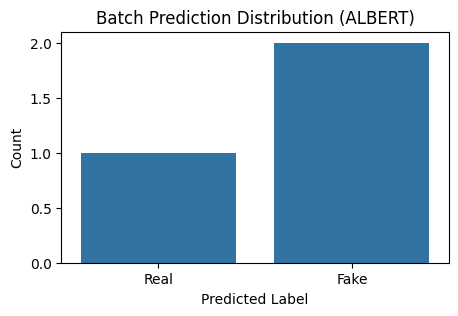

In [6]:
# Visualize prediction distribution for ensemble and batch results
import numpy as np

# Ensemble votes distribution
if 'votes' in ensemble_result:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=ensemble_result['votes'])
    plt.title('Ensemble Model Votes Distribution')
    plt.xlabel('Predicted Label')
    plt.ylabel('Count')
    plt.show()

# Batch prediction distribution
if 'predictions' in batch_response.json():
    plt.figure(figsize=(5, 3))
    sns.countplot(x=batch_response.json()['predictions'])
    plt.title('Batch Prediction Distribution (ALBERT)')
    plt.xlabel('Predicted Label')
    plt.ylabel('Count')
    plt.show()